In [10]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import warnings

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

In [12]:
warnings.filterwarnings("ignore")

In [13]:
# Import datasets 
df = pd.read_csv("Position_Salaries.csv")

In [14]:
print(df.head())

            Position  Level  Salary
0   Business Analyst      1   45000
1  Junior Consultant      2   50000
2  Senior Consultant      3   60000
3            Manager      4   80000
4    Country Manager      5  110000


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Position  10 non-null     object
 1   Level     10 non-null     int64 
 2   Salary    10 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 372.0+ bytes


In [19]:
X = df.iloc[:,1:2].values
y = df.iloc[:,2].values

In [21]:
label_encoder = LabelEncoder()

for col in df.select_dtypes(include=["object"]).columns:
    df[col] = label_encoder.fit_transform(df[col])

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [23]:
regressor = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    oob_score=True
)


In [24]:
regressor.fit(X_train, y_train)

RandomForestRegressor(oob_score=True, random_state=42)

In [25]:
print("Out-of-Bag Score:", regressor.oob_score_)

y_pred = regressor.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

r2 = r2_score(y_test, y_pred)
print("R-squared:", r2)

Out-of-Bag Score: 0.2280694384742593
Mean Squared Error: 616145000.0
R-squared: 0.9878292345679013


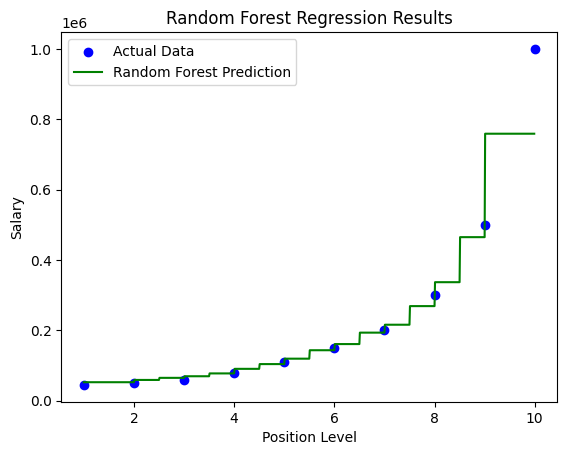

In [26]:
import numpy as np
import matplotlib.pyplot as plt

X_grid = np.arange(min(X), max(X), 0.01).reshape(-1,1)

plt.scatter(X, y, color='blue', label="Actual Data")
plt.plot(X_grid, regressor.predict(X_grid), color='green', label="Random Forest Prediction")

plt.title("Random Forest Regression Results")
plt.xlabel('Position Level')
plt.ylabel('Salary')
plt.legend()
plt.show()

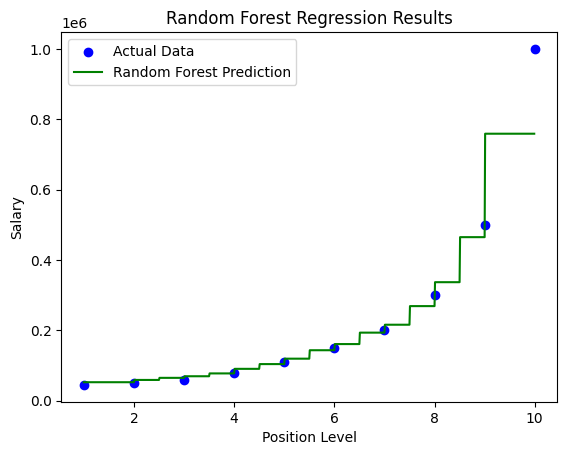

In [27]:
import numpy as np
import matplotlib.pyplot as plt

X_grid = np.arange(min(X), max(X), 0.01).reshape(-1,1)

plt.scatter(X, y, color='blue', label="Actual Data")
plt.plot(X_grid, regressor.predict(X_grid), color='green', label="Random Forest Prediction")

plt.title("Random Forest Regression Results")
plt.xlabel('Position Level')
plt.ylabel('Salary')
plt.legend()
plt.show()

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

tree_to_plot = regressor.estimators_[0]

plt.figure(figsize=(20, 10))
plot_tree(tree_to_plot, feature_names=df.columns.tolist(), filled=True, rounded=True, fontsize=10)
plt.title("Decision Tree from Random Forest")
plt.show()